In [1]:
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.util import cos_sim
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
from sklearn.model_selection import train_test_split

In [2]:
baseline_path = 'models/baseline_e5_small_20260123_142130'
curriculum_path = 'models/curriculum_e5_small_20260123_143310/final_model'

baseline_model = SentenceTransformer(baseline_path)
print(f" Baseline модель загружена: {baseline_path}")

curriculum_model = SentenceTransformer(curriculum_path)
print(f" Curriculum модель загружена: {curriculum_path}")

The tokenizer you are loading from 'models/baseline_e5_small_20260123_142130' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


 Baseline модель загружена: models/baseline_e5_small_20260123_142130


The tokenizer you are loading from 'models/curriculum_e5_small_20260123_143310/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


 Curriculum модель загружена: models/curriculum_e5_small_20260123_143310/final_model


In [3]:
df_full = pd.read_csv('miracl_ru_train_prepared.csv', encoding='utf-8')

df_test = df_full.sort_values('difficulty', ascending=False).head(500)

print(f"  Tренировочный набор: {len(df_test)} примеров")
print(f"  Разброс сложности: {df_test['difficulty'].min():.3f} - {df_test['difficulty'].max():.3f}")
print(f"  Уникальных запросов: {df_test['query_id'].nunique()}")

test_queries = [f"query: {q}" for q in df_test['query'].tolist()]
test_passages = [f"passage: {p}" for p in df_test['passage'].tolist()]

print(f"  Подготовлено {len(test_queries)} запрос-ответ пар")

  Tренировочный набор: 500 примеров
  Разброс сложности: 0.520 - 0.826
  Уникальных запросов: 421
  Подготовлено 500 запрос-ответ пар


Вычмсляем представления:

In [4]:
print("\n  Baseline модель")
baseline_query_embs = baseline_model.encode(
    test_queries, 
    show_progress_bar=True,
    convert_to_tensor=True
)
baseline_passage_embs = baseline_model.encode(
    test_passages, 
    show_progress_bar=True,
    convert_to_tensor=True
)

print("\n  Curriculum модель")
curriculum_query_embs = curriculum_model.encode(
    test_queries, 
    show_progress_bar=True,
    convert_to_tensor=True
)
curriculum_passage_embs = curriculum_model.encode(
    test_passages, 
    show_progress_bar=True,
    convert_to_tensor=True
)

print(f"\n Представления вычислены")


  Baseline модель


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


  Curriculum модель


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


 Представления вычислены


Вычисляем косинусное сходство представлений:

In [5]:
baseline_similarities = []
curriculum_similarities = []

for i in range(len(test_queries)):
    baseline_sim = cos_sim(baseline_query_embs[i], baseline_passage_embs[i]).item()
    curriculum_sim = cos_sim(curriculum_query_embs[i], curriculum_passage_embs[i]).item()
    
    baseline_similarities.append(baseline_sim)
    curriculum_similarities.append(curriculum_sim)

df_test['baseline_similarity'] = baseline_similarities
df_test['curriculum_similarity'] = curriculum_similarities

Среднее сходство:

In [6]:
baseline_mean = np.mean(baseline_similarities)
curriculum_mean = np.mean(curriculum_similarities)
diff_mean = curriculum_mean - baseline_mean

print(f"{'Среднее сзодство':<30} {baseline_mean:<15.4f} {curriculum_mean:<15.4f} {diff_mean:+.4f}")

Среднее сзодство               0.6969          0.7062          +0.0093


Медианное сходство:

In [7]:
baseline_median = np.median(baseline_similarities)
curriculum_median = np.median(curriculum_similarities)
diff_median = curriculum_median - baseline_median

print(f"{'Медианное сходство':<30} {baseline_median:<15.4f} {curriculum_median:<15.4f} {diff_median:+.4f}")

Медианное сходство             0.7146          0.7142          -0.0004


Стандартное отклонение:

In [8]:
baseline_std = np.std(baseline_similarities)
curriculum_std = np.std(curriculum_similarities)
diff_std = curriculum_std - baseline_std

print(f"{'Std Deviation':<30} {baseline_std:<15.4f} {curriculum_std:<15.4f} {diff_std:+.4f}")

Std Deviation                  0.1002          0.0876          -0.0126


Минимум и максимум:

In [9]:
baseline_min = np.min(baseline_similarities)
curriculum_min = np.min(curriculum_similarities)
diff_min = curriculum_min - baseline_min

print(f"{'Минимальное сходство':<30} {baseline_min:<15.4f} {curriculum_min:<15.4f} {diff_min:+.4f}")

baseline_max = np.max(baseline_similarities)
curriculum_max = np.max(curriculum_similarities)
diff_max = curriculum_max - baseline_max

print(f"{'Максимальное сходство':<30} {baseline_max:<15.4f} {curriculum_max:<15.4f} {diff_max:+.4f}")

Минимальное сходство           0.2532          0.4417          +0.1885
Максимальное сходство          0.8830          0.8912          +0.0081


In [10]:
unique_queries = df_full['query_id'].unique()
train_queries, test_queries = train_test_split(unique_queries, test_size=0.2, random_state=42)
df_test = df_full[df_full['query_id'].isin(test_queries)]

In [11]:
test_qrels = {} 

for query_id in df_test['query_id'].unique():
    relevant_docs = df_test[df_test['query_id'] == query_id]['docid'].tolist()
    test_qrels[query_id] = relevant_docs

In [12]:
corpus_docs = df_test[['docid', 'passage']].drop_duplicates('docid')
corpus_map = dict(zip(corpus_docs['docid'], corpus_docs['passage']))

In [13]:
df_train = df_full[df_full['query_id'].isin(train_queries)]
distractor_docs = df_train.sample(min(1000, len(df_train)), random_state=42)

In [14]:
for _, row in distractor_docs.iterrows():
    if row['docid'] not in corpus_map:
        corpus_map[row['docid']] = row['passage']

In [15]:
queries_map = dict(zip(df_test['query_id'], df_test['query']))
queries_map = {qid: q for qid, q in queries_map.items() if qid in test_qrels}

print(f" Queries: {len(queries_map)}")

 Queries: 362


In [16]:
def calculate_ndcg_at_k(ranked_list, relevant_docs, k=10):
    """
    Normalized Discounted Cumulative Gain
    """
    dcg = 0.0
    idcg = 0.0
    
    for i, doc_id in enumerate(ranked_list[:k]):
        if doc_id in relevant_docs:
            dcg += 1.0 / np.log2(i + 2)
    
    for i in range(min(len(relevant_docs), k)):
        idcg += 1.0 / np.log2(i + 2)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg

In [17]:
def calculate_mrr(ranked_list, relevant_docs):
    """
    Mean Reciprocal Rank
    """
    for i, doc_id in enumerate(ranked_list):
        if doc_id in relevant_docs:
            return 1.0 / (i + 1)
    return 0.0

In [18]:
def calculate_map_at_k(ranked_list, relevant_docs, k=10):
    """
    Mean Average Precision
    """
    if len(relevant_docs) == 0:
        return 0.0
    
    score = 0.0
    num_relevant_found = 0
    
    for i, doc_id in enumerate(ranked_list[:k]):
        if doc_id in relevant_docs:
            num_relevant_found += 1
            precision_at_i = num_relevant_found / (i + 1)
            score += precision_at_i
    
    if num_relevant_found == 0:
        return 0.0
    
    return score / min(len(relevant_docs), k)

In [19]:
def calculate_recall_at_k(ranked_list, relevant_docs, k=10):
    """
    Recall at K - сколько релевантных нашли из всех
    """
    if len(relevant_docs) == 0:
        return 0.0
    
    found = sum(1 for doc_id in ranked_list[:k] if doc_id in relevant_docs)
    return found / len(relevant_docs)

In [20]:
def evaluate_model(model, model_name):
    print(f"Оцениваем: {model_name}")
    
    corpus_ids = list(corpus_map.keys())
    corpus_texts = [f"passage: {corpus_map[doc_id]}" for doc_id in corpus_ids]
    
    corpus_embeddings = model.encode(
        corpus_texts,
        convert_to_tensor=True,
        show_progress_bar=True
    )
    
    ndcg_at_10_scores = []
    ndcg_at_5_scores = []
    mrr_scores = []
    map_at_10_scores = []
    recall_at_10_scores = []
    recall_at_5_scores = []
    
    print("  Оцениваем запросы...")
    
    for query_id, query_text in tqdm(queries_map.items(), desc=f"  {model_name}"):
        query_embedding = model.encode(
            f"query: {query_text}",
            convert_to_tensor=True
        )
        
        similarities = util.cos_sim(query_embedding, corpus_embeddings)[0]
        
        ranked_indices = similarities.argsort(descending=True).cpu().tolist()
        ranked_doc_ids = [corpus_ids[idx] for idx in ranked_indices]
        
        relevant_docs = test_qrels[query_id]
        
        ndcg_at_10_scores.append(calculate_ndcg_at_k(ranked_doc_ids, relevant_docs, k=10))
        ndcg_at_5_scores.append(calculate_ndcg_at_k(ranked_doc_ids, relevant_docs, k=5))
        mrr_scores.append(calculate_mrr(ranked_doc_ids, relevant_docs))
        map_at_10_scores.append(calculate_map_at_k(ranked_doc_ids, relevant_docs, k=10))
        recall_at_10_scores.append(calculate_recall_at_k(ranked_doc_ids, relevant_docs, k=10))
        recall_at_5_scores.append(calculate_recall_at_k(ranked_doc_ids, relevant_docs, k=5))
    
    results = {
        'NDCG@10': np.mean(ndcg_at_10_scores),
        'NDCG@5': np.mean(ndcg_at_5_scores),
        'MRR': np.mean(mrr_scores),
        'MAP@10': np.mean(map_at_10_scores),
        'Recall@10': np.mean(recall_at_10_scores),
        'Recall@5': np.mean(recall_at_5_scores)
    }
    
    return results, {
        'ndcg_at_10': ndcg_at_10_scores,
        'mrr': mrr_scores,
        'map_at_10': map_at_10_scores
    }

In [21]:
baseline_results, baseline_detailed = evaluate_model(baseline_model, "BASELINE")
curriculum_results, curriculum_detailed = evaluate_model(curriculum_model, "CURRICULUM")

Оцениваем: BASELINE


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

  Оцениваем запросы...


  BASELINE: 100%|███████████████████████████████████████████████████████████████████| 362/362 [00:02<00:00, 179.43it/s]

Оцениваем: CURRICULUM


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

  Оцениваем запросы...


  CURRICULUM: 100%|█████████████████████████████████████████████████████████████████| 362/362 [00:02<00:00, 180.03it/s]


In [22]:
for metric_name in baseline_results.keys():
    baseline_val = baseline_results[metric_name]
    curriculum_val = curriculum_results[metric_name]
    diff = curriculum_val - baseline_val
    improvement_pct = (diff / baseline_val * 100) if baseline_val > 0 else 0

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

metrics = ['NDCG@10', 'NDCG@5', 'MRR', 'MAP@10', 'Recall@10', 'Recall@5']
baseline_scores = [0.7507, 0.7477, 0.7424, 0.7308, 0.7952, 0.7852]
curriculum_scores = [0.7621, 0.7587, 0.7540, 0.7456, 0.8000, 0.7896]
improvements = [1.06, 1.03, 1.13, 1.29, 0.43, 0.41]

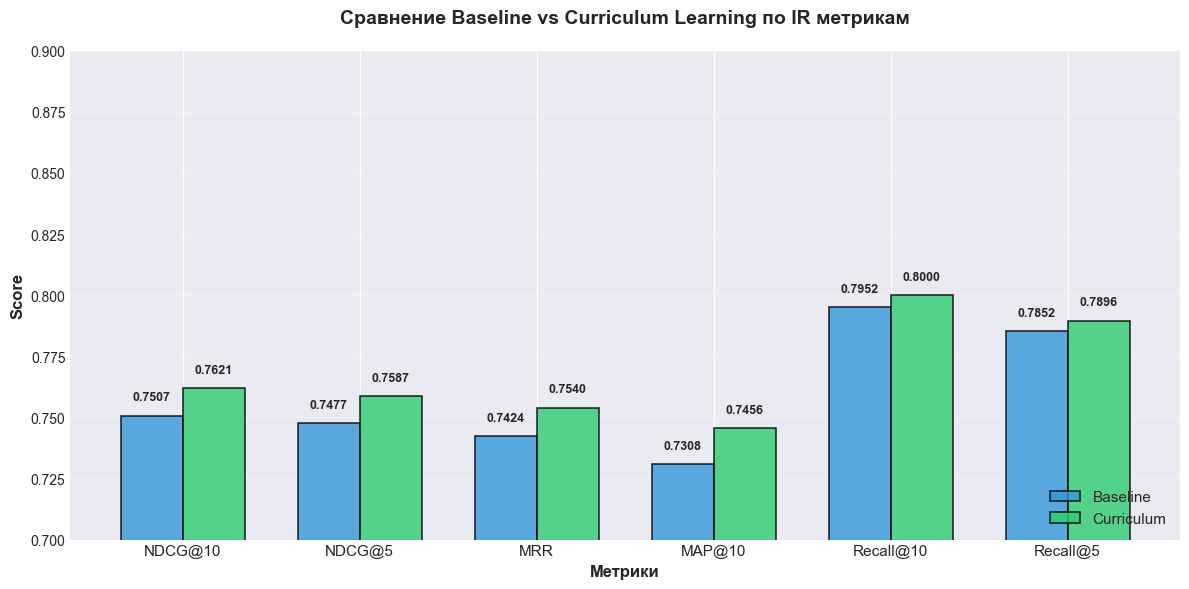

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, curriculum_scores, width, label='Curriculum', 
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.2)

for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.005,
            f'{height1:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.005,
            f'{height2:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Метрики', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Сравнение Baseline vs Curriculum Learning по IR метрикам', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0.70, 0.90])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparison_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Александр\AppData\Local\Temp\ipykernel_21936\2231214844.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(metrics, fontsize=10, rotation=15, ha='right')


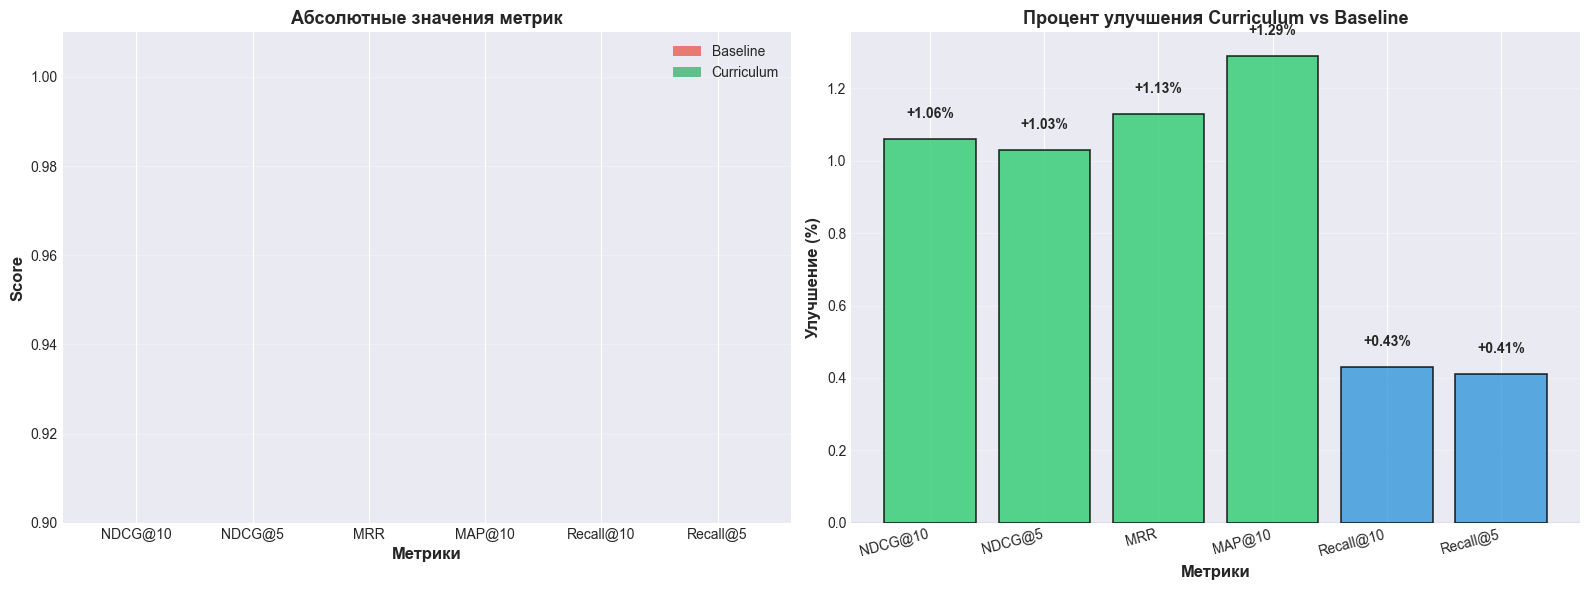

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


x = np.arange(len(metrics))
width = 0.35

ax1.bar(x - width/2, baseline_scores, width, label='Baseline', 
        color='#e74c3c', alpha=0.7)
ax1.bar(x + width/2, curriculum_scores, width, label='Curriculum', 
        color='#27ae60', alpha=0.7)

ax1.set_xlabel('Метрики', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Абсолютные значения метрик', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.legend(fontsize=10)
ax1.set_ylim([0.90, 1.01])
ax1.grid(True, alpha=0.3, axis='y')

colors = ['#2ecc71' if imp > 1.0 else '#3498db' for imp in improvements]
bars = ax2.bar(metrics, improvements, color=colors, alpha=0.8, 
               edgecolor='black', linewidth=1.2)

for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'+{imp:.2f}%', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

ax2.set_ylabel('Улучшение (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Метрики', fontsize=12, fontweight='bold')
ax2.set_title('Процент улучшения Curriculum vs Baseline', 
              fontsize=13, fontweight='bold')
ax2.set_xticklabels(metrics, fontsize=10, rotation=15, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('comparison_improvements.png', dpi=300, bbox_inches='tight')
plt.show()
